# DEM ALOS PALSAR (12.5 m) — Volcán Villarrica

Lee y une **solo** los DEM ALOS PALSAR locales de `ALOS PALSAR/*.jp2` (JPEG-2000, `uint16`, UTM 18S / EPSG:32718,
píxel de 12.5 m):

| Archivo | Región |
|---|---|
| `9.jp2` | IX de La Araucanía |
| `14.jp2` | XIV de Los Ríos |
| `10.jp2` | X de Los Lagos |

y los entrega en **UTM 19S (EPSG:32719)** con la misma salida que `get_dem()` de `DEM.ipynb`:
`X, Y, Z, tr = get_dem_alos(...)`, para poder usarlo como reemplazo directo.

Cada archivo está recortado por el límite de su región (fuera de ella los píxeles valen 0). Donde dos regiones
se tocan, los DEM coinciden (9/14: diferencia mediana 0.0 m, σ ≈ 1.7 m; 14/10: 0.0 m, σ ≈ 1.6 m) y se promedian;
la ranura de pocos píxeles que queda entre polígonos vecinos se interpola.

**Cobertura en el Villarrica:** con La Araucanía (flanco norte, Pucón) y Los Ríos (flanco sur, Coñaripe) el volcán
queda completo. Lo único que no cubre ALOS es **Argentina**: un dominio de 50 × 45 km centrado en el cráter
pierde una esquina SE de ~3.6 × 7 km (0.9 %). Por eso el ejemplo usa 42 × 45 km, que queda 100 % cubierto.
Si el dominio tiene píxeles sin dato, `get_dem_alos()` da error; con `allow_nan=True` los devuelve como `NaN`.

In [1]:
"""
DEM ALOS PALSAR (12.5 m) para el Volcán Villarrica, con tamaño de dominio variable.
Usa SOLO los .jp2 de la carpeta "ALOS PALSAR" (9 = La Araucanía, 14 = Los Ríos, 10 = Los Lagos).

Dependencias:
    pip install rasterio numpy scipy matplotlib pyproj
    (rasterio necesita el driver JP2OpenJPEG; las ruedas de pip ya lo traen)

Uso rápido:
    X, Y, Z, tr = get_dem_alos(lon0=-71.94, lat0=-39.42, half_x_km=21, half_y_km=22.5)  # Villarrica
    X, Y, Z, tr = get_dem_alos(lon0=-72.12, lat0=-40.55, half_x_km=15)  # Puyehue-Cordón Caulle

Salida:
    X, Y : coordenadas UTM 19S (EPSG:32719) en metros, centros de píxel (2D)
    Z    : elevación en metros (2D, float32)
    tr   : transform (affine) del recorte, por si quieres guardarlo como GeoTIFF
"""

import os
from glob import glob

import numpy as np
import rasterio
from pyproj import Transformer
from rasterio.crs import CRS
from rasterio.errors import WindowError
from rasterio.fill import fillnodata
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject, transform_bounds
from rasterio.windows import Window, from_bounds
from scipy.ndimage import binary_closing

UTM_CRS = "EPSG:32719"  # WGS84 / UTM 19S (zona del Villarrica)
ALOS_PATHS = sorted(glob("ALOS PALSAR/*.jp2"))
ALOS_REGIONS = {"9": "La Araucanía", "10": "Los Lagos", "14": "Los Ríos"}
ALOS_CRS = "EPSG:32718"  # UTM 18S: se usa si el JP2 no trae CRS y no hay .prj
ALOS_NODATA = 0  # el JP2 no declara nodata: fuera de la región los píxeles vienen en 0
SEAM_PX = 5      # ancho máximo (píxeles) de la ranura sin dato entre regiones que se interpola

_to_utm = Transformer.from_crs("EPSG:4326", UTM_CRS, always_xy=True)


def region_name(path):
    """Nombre de la región a partir del archivo (p.ej. 'ALOS PALSAR/9.jp2' -> 'La Araucanía')."""
    key = os.path.splitext(os.path.basename(path))[0]
    return ALOS_REGIONS.get(key, key)


# ---------------------------------------------------------------------------
# 1. Utilidades de geometría
# ---------------------------------------------------------------------------
def bounds_from_center(lon0, lat0, half_x_km, half_y_km=None):
    """Rectángulo (xmin, ymin, xmax, ymax) en metros UTM 19S alrededor de (lon0, lat0)."""
    half_y_km = half_y_km if half_y_km is not None else half_x_km
    x0, y0 = _to_utm.transform(lon0, lat0)
    return (x0 - half_x_km * 1e3, y0 - half_y_km * 1e3,
            x0 + half_x_km * 1e3, y0 + half_y_km * 1e3)


def target_grid(bounds, res):
    """Transform y forma (filas, columnas) de la grilla UTM 19S sobre el rectángulo exacto."""
    xmin, ymin, xmax, ymax = bounds
    nc = int(round((xmax - xmin) / res))
    nr = int(round((ymax - ymin) / res))
    return from_origin(xmin, ymax, res, res), (nr, nc)


# ---------------------------------------------------------------------------
# 2. Lectura y reproyección
# ---------------------------------------------------------------------------
def alos_crs(src, path):
    """CRS del JP2: el incrustado o, si no trae (pasa con 10.jp2), el de su .prj."""
    if src.crs is not None:
        return src.crs
    prj = os.path.splitext(path)[0] + ".prj"
    if os.path.exists(prj):
        with open(prj) as f:
            return CRS.from_wkt(f.read())
    return CRS.from_string(ALOS_CRS)


def read_alos_file(path, tr, shape, margin_m=500.0):
    """Reproyecta UN archivo ALOS (UTM 18S) sobre la grilla UTM 19S (tr, shape). NaN = sin dato."""
    nr, nc = shape
    xmin, ymax = tr.c, tr.f
    xmax, ymin = xmin + nc * tr.a, ymax + nr * tr.e
    out = np.full(shape, np.nan, dtype="float32")

    with rasterio.open(path) as src:
        src_crs = alos_crs(src, path)
        # Solo se lee la ventana del archivo que cubre el dominio (+ margen)
        sb = transform_bounds(UTM_CRS, src_crs, xmin - margin_m, ymin - margin_m,
                              xmax + margin_m, ymax + margin_m)
        try:
            win = (from_bounds(*sb, transform=src.transform)
                   .round_offsets().round_lengths()
                   .intersection(Window(0, 0, src.width, src.height)))
        except WindowError:  # el dominio no toca el archivo
            return out
        data = src.read(1, window=win).astype("float32")
        src_tr = src.window_transform(win)

    data[data == ALOS_NODATA] = np.nan
    reproject(
        data, out,
        src_transform=src_tr, src_crs=src_crs, src_nodata=np.nan,
        dst_transform=tr, dst_crs=UTM_CRS, dst_nodata=np.nan,
        resampling=Resampling.bilinear,
    )
    return out


def read_alos(tr, shape, paths=ALOS_PATHS, seam_px=SEAM_PX):
    """Mosaico de todos los archivos ALOS sobre la grilla UTM 19S. NaN = sin dato.

    Donde dos regiones se solapan se promedian. La ranura angosta que queda entre
    polígonos vecinos se interpola, pero sin extrapolar hacia fuera de la cobertura.
    """
    acc = np.zeros(shape, dtype="float64")
    cnt = np.zeros(shape, dtype="int16")
    for p in paths:
        z = read_alos_file(p, tr, shape)
        ok = ~np.isnan(z)
        acc[ok] += z[ok]
        cnt[ok] += 1
    valid = cnt > 0
    out = np.where(valid, acc / np.maximum(cnt, 1), np.nan).astype("float32")

    if seam_px and valid.any() and not valid.all():
        seam = binary_closing(valid, iterations=seam_px) & ~valid
        if seam.any():
            filled = fillnodata(out, mask=valid, max_search_distance=2 * seam_px)
            out[seam] = filled[seam]
    return out


def alos_coverage(paths=ALOS_PATHS):
    """Límites de cada archivo ALOS en lon/lat {nombre: (W, S, E, N)}. Ojo: dentro hay zonas sin dato."""
    cov = {}
    for p in paths:
        with rasterio.open(p) as src:
            cov[os.path.basename(p)] = transform_bounds(alos_crs(src, p), "EPSG:4326", *src.bounds)
    return cov


# ---------------------------------------------------------------------------
# 3. DEM final recortado al dominio
# ---------------------------------------------------------------------------
def get_dem_alos(lon0, lat0, half_x_km, half_y_km=None, res=12.5, paths=ALOS_PATHS,
                 allow_nan=False):
    """DEM ALOS PALSAR en UTM 19S, recortado al dominio pedido.

    lon0, lat0 : centro del dominio (grados, WGS84)
    half_x_km  : semi-ancho E-O en km (dominio total = 2 * half_x_km)
    half_y_km  : semi-alto N-S en km (por defecto igual a half_x_km)
    res        : tamaño de píxel de salida en metros (nativo = 12.5 m)
    paths      : archivos ALOS a unir (por defecto todos los .jp2 de "ALOS PALSAR")
    allow_nan  : si False (por defecto) da error cuando parte del dominio queda fuera de
                 la cobertura ALOS; si True devuelve esos píxeles como NaN
    """
    if not paths:
        raise FileNotFoundError("No hay archivos .jp2 en 'ALOS PALSAR/' (¿directorio de trabajo?).")
    tr, shape = target_grid(bounds_from_center(lon0, lat0, half_x_km, half_y_km), res)
    Z = read_alos(tr, shape, paths)

    holes = np.isnan(Z)
    if holes.any():
        rows, cols = np.where(holes)
        lados = [nombre for nombre, toca in (
            ("norte", rows.min() == 0), ("sur", rows.max() == shape[0] - 1),
            ("oeste", cols.min() == 0), ("este", cols.max() == shape[1] - 1)) if toca]
        msg = (f"{100 * holes.mean():.2f}% del dominio no tiene dato ALOS "
               f"(borde {', '.join(lados) or 'interior'}; fuera de las regiones "
               f"{', '.join(region_name(p) for p in paths)}, p.ej. Argentina o el mar).")
        if not allow_nan:
            raise ValueError(msg + " Achica o mueve el dominio, o usa allow_nan=True.")
        print("Aviso: " + msg + " Esos píxeles quedan como NaN.")

    # Coordenadas (centros de píxel) en metros UTM
    rows, cols = np.indices(Z.shape)
    X = tr.c + (cols + 0.5) * tr.a
    Y = tr.f + (rows + 0.5) * tr.e
    return X, Y, Z, tr


# ---------------------------------------------------------------------------
# 4. Guardado y derivadas del terreno
# ---------------------------------------------------------------------------
def save_geotiff(path, Z, tr):
    """Guarda el DEM recortado como GeoTIFF en UTM 19S."""
    with rasterio.open(
        path, "w", driver="GTiff",
        height=Z.shape[0], width=Z.shape[1], count=1, dtype="float32",
        crs=UTM_CRS, transform=tr, nodata=np.nan,
    ) as dst:
        dst.write(Z.astype("float32"), 1)


def terrain_derivatives(Z, tr):
    """dz/dx (este), dz/dy (norte) y pendiente en grados."""
    dx, dy = tr.a, -tr.e  # tr.e es negativo (las filas crecen hacia el sur)
    dzdx = np.gradient(Z, dx, axis=1)
    dzdy = -np.gradient(Z, dy, axis=0)  # signo: filas crecen hacia el sur
    slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
    return dzdx, dzdy, slope


## Cobertura de los archivos ALOS y dominio pedido

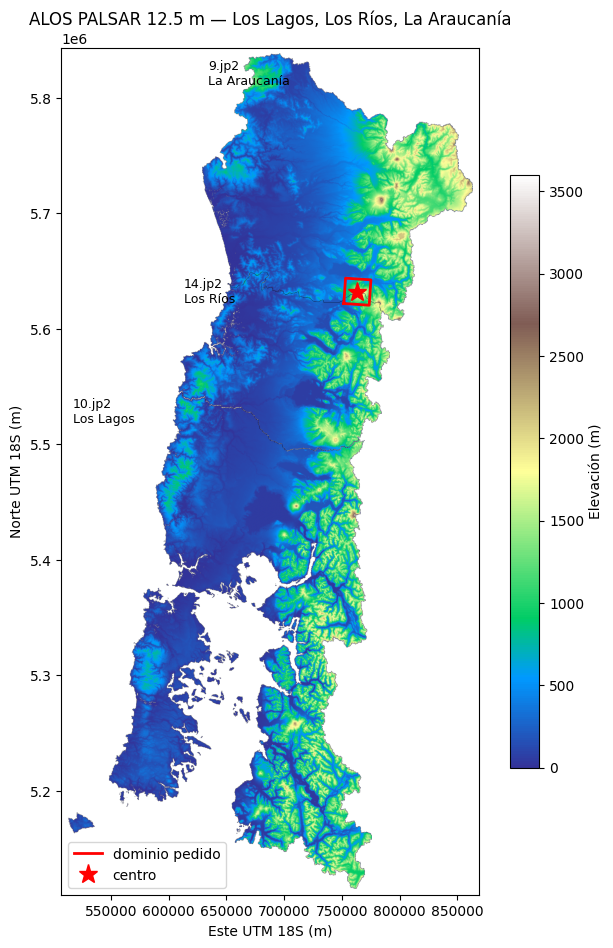

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# Parámetros del dominio (cambia estos valores para variar el tamaño)
LON0, LAT0 = -71.94, -39.42      # cerca del cráter (aprox.)
HALF_X_KM, HALF_Y_KM = 11, 11  # dominio de 42 x 45 km (con 25 km la esquina SE cae en Argentina)
RES = 12.5                        # metros por píxel (nativo ALOS)

# Vista general de cada archivo (reducido x24) con el dominio encima
fig, ax = plt.subplots(figsize=(8, 11))
lims = []
for p in ALOS_PATHS:
    with rasterio.open(p) as src:
        f = 24
        ov = src.read(1, out_shape=(src.height // f, src.width // f)).astype("float32")
        b, crs18 = src.bounds, alos_crs(src, p)
    ov[ov == ALOS_NODATA] = np.nan
    im = ax.imshow(ov, cmap="terrain", vmin=0, vmax=3600, extent=(b.left, b.right, b.bottom, b.top))
    ax.text(b.left + 5e3, b.top - 5e3, f"{os.path.basename(p)}\n{region_name(p)}",
            ha="left", va="top", fontsize=9)
    lims.append(b)

xmin, ymin, xmax, ymax = bounds_from_center(LON0, LAT0, HALF_X_KM, HALF_Y_KM)
t = np.linspace(0, 1, 50)
ring_x = np.r_[xmin + t * (xmax - xmin), np.full(50, xmax), xmax - t * (xmax - xmin), np.full(50, xmin)]
ring_y = np.r_[np.full(50, ymin), ymin + t * (ymax - ymin), np.full(50, ymax), ymax - t * (ymax - ymin)]
rx, ry = Transformer.from_crs(UTM_CRS, crs18, always_xy=True).transform(ring_x, ring_y)
vx, vy = Transformer.from_crs("EPSG:4326", crs18, always_xy=True).transform(LON0, LAT0)

ax.plot(rx, ry, "r-", lw=2, label="dominio pedido")
ax.plot(vx, vy, "r*", ms=14, label="centro")
ax.set_xlim(min(min(b.left for b in lims), rx.min()) - 5e3, max(max(b.right for b in lims), rx.max()) + 5e3)
ax.set_ylim(min(min(b.bottom for b in lims), ry.min()) - 5e3, max(max(b.top for b in lims), ry.max()) + 5e3)
plt.colorbar(im, ax=ax, label="Elevación (m)", shrink=0.7)
ax.set_xlabel("Este UTM 18S (m)")
ax.set_ylabel("Norte UTM 18S (m)")
ax.set_title("ALOS PALSAR 12.5 m — " + ", ".join(region_name(p) for p in ALOS_PATHS))
ax.legend(loc="lower left")
plt.show()

## DEM recortado en UTM 19S

DEM: 1760 x 1760 píxeles, z entre 212 y 2853 m


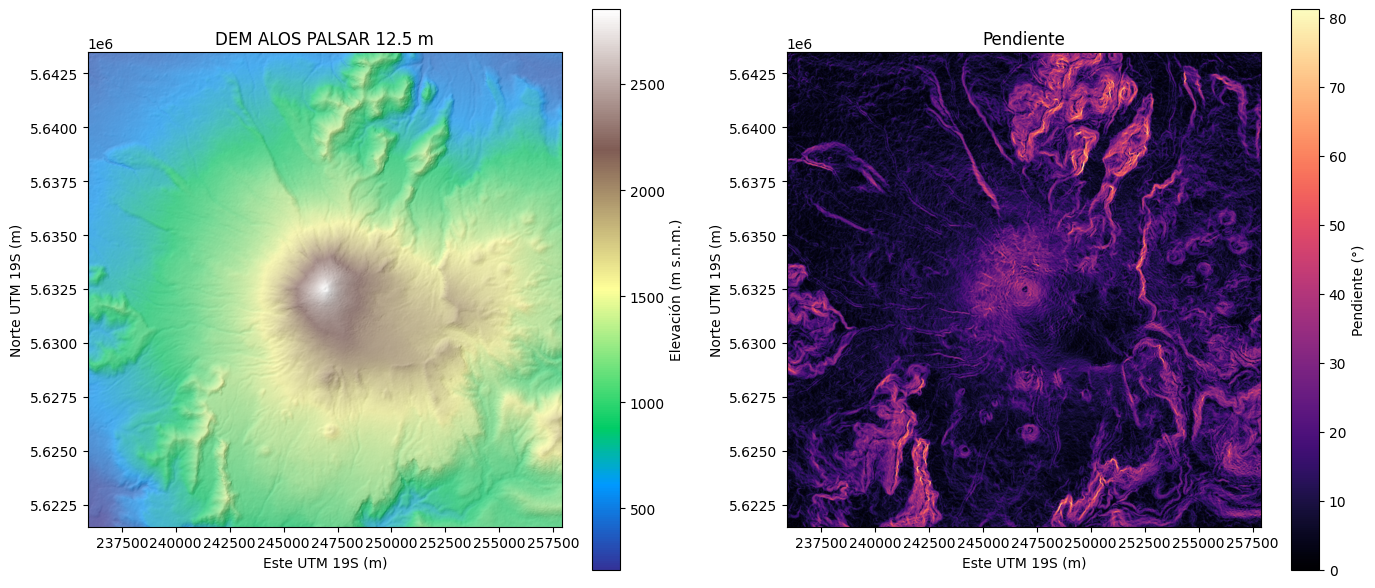

In [9]:
X, Y, Z, tr = get_dem_alos(LON0, LAT0, HALF_X_KM, HALF_Y_KM, res=RES)
print(f"DEM: {Z.shape[0]} x {Z.shape[1]} píxeles, "
      f"z entre {np.nanmin(Z):.0f} y {np.nanmax(Z):.0f} m")

save_geotiff("villarrica_dem_alos_utm19s.tif", Z, tr)
dzdx, dzdy, slope = terrain_derivatives(Z, tr)

# Visualización con relieve sombreado
extent = (tr.c, tr.c + Z.shape[1] * tr.a, tr.f + Z.shape[0] * tr.e, tr.f)
hill = LightSource(azdeg=315, altdeg=45).hillshade(
    np.nan_to_num(Z, nan=np.nanmin(Z)), vert_exag=1, dx=tr.a, dy=-tr.e
)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
im0 = ax[0].imshow(Z, cmap="terrain", extent=extent)
ax[0].imshow(hill, cmap="gray", alpha=0.35, extent=extent)
plt.colorbar(im0, ax=ax[0], label="Elevación (m s.n.m.)")
ax[0].set_title("DEM ALOS PALSAR 12.5 m")

im1 = ax[1].imshow(slope, cmap="magma", extent=extent)
plt.colorbar(im1, ax=ax[1], label="Pendiente (°)")
ax[1].set_title("Pendiente")

for a in ax:
    a.set_xlabel("Este UTM 19S (m)")
    a.set_ylabel("Norte UTM 19S (m)")
plt.tight_layout()
plt.show()

## Origen de cada píxel y unión entre regiones

Muestra de qué archivo sale cada píxel del dominio y cuánto difieren los DEM donde dos regiones se solapan
(debería ser ~0 m; una diferencia grande indicaría un escalón artificial en $\nabla z_b$).

Los Ríos - La Araucanía: 686 píxeles en común, mediana +0.00 m, desv. est. 1.65 m
Ranura interpolada: 7 píxeles; sin dato: 0 píxeles


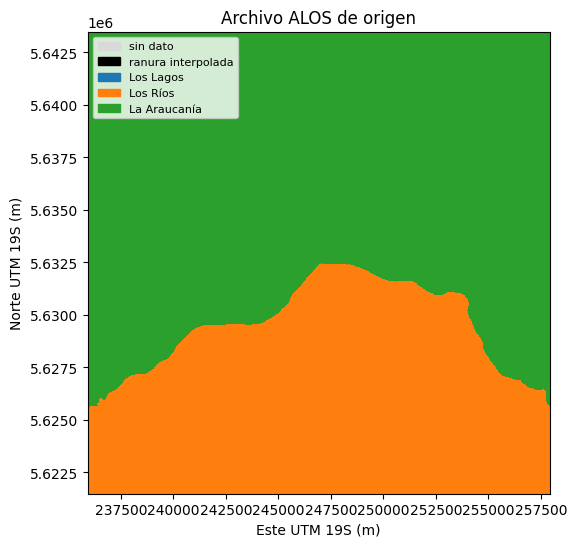

In [10]:
from matplotlib.colors import ListedColormap

src_id = np.full(Z.shape, -1, dtype=int)  # -1 = sin dato, -2 = ranura interpolada
zs = {}
for i, p in enumerate(ALOS_PATHS):
    zs[p] = read_alos_file(p, tr, Z.shape)
    src_id[~np.isnan(zs[p]) & (src_id == -1)] = i
src_id[(src_id == -1) & ~np.isnan(Z)] = -2

for i, p in enumerate(ALOS_PATHS):
    for q in ALOS_PATHS[i + 1:]:
        both = ~np.isnan(zs[p]) & ~np.isnan(zs[q])
        if both.any():
            d = zs[p][both] - zs[q][both]
            print(f"{region_name(p)} - {region_name(q)}: {both.sum()} píxeles en común, "
                  f"mediana {np.median(d):+.2f} m, desv. est. {d.std():.2f} m")
print(f"Ranura interpolada: {(src_id == -2).sum()} píxeles; sin dato: {(src_id == -1).sum()} píxeles")

colors = ["0.85", "k"] + [plt.cm.tab10(i) for i in range(len(ALOS_PATHS))]
labels = ["sin dato", "ranura interpolada"] + [region_name(p) for p in ALOS_PATHS]
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(src_id + 2, cmap=ListedColormap(colors), vmin=-0.5, vmax=len(colors) - 0.5,
          extent=extent, interpolation="nearest")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in colors], labels=labels,
          loc="upper left", fontsize=8)
ax.set_xlabel("Este UTM 19S (m)")
ax.set_ylabel("Norte UTM 19S (m)")
ax.set_title("Archivo ALOS de origen")
plt.show()